# Part 3 — Statistical Analysis

Responder vs non-responder comparison: melanoma + miraclib + PBMC, baseline (t=0) only.
Record of the analysis already implemented in `src/domain/statistics.py`, kept here for visibility (not part of the pipeline).

In [1]:
%load_ext autoreload
%autoreload 2

import sys, sqlite3
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # repo root, so `src` imports work

from src.data.repository import get_annotated_cell_counts
from src.domain.statistics import filter_predictive_subset, compute_response_frequencies

conn = sqlite3.connect(Path.cwd().parent / "cell_counts.db")
annotated = get_annotated_cell_counts(conn)
conn.close()

subset = filter_predictive_subset(annotated)
freq = compute_response_frequencies(subset)
freq.shape, freq["sample_id"].nunique()

((3280, 6), 656)

In [2]:
from src.domain.statistics import compare_responders

pd.set_option("display.width", 200)
stats = compare_responders(freq)
stats

,population,n_responder,n_non_responder,median_responder,median_non_responder,iqr_responder,iqr_non_responder,u_statistic,p_value,cliffs_delta,q_value
0,b_cell,331,325,9.785035,9.758175,4.211664,4.030093,55244.0,0.548541,0.027079,0.885328
1,cd8_t_cell,331,325,24.395688,24.601028,6.782532,5.326785,52203.0,0.513956,-0.029459,0.885328
2,cd4_t_cell,331,325,29.633822,29.530535,6.815738,6.243989,54414.0,0.796450,0.011648,0.885328
3,nk_cell,331,325,14.997332,14.890454,6.015193,4.634497,53437.0,0.885328,-0.006516,0.885328
4,monocyte,331,325,19.605580,20.286002,6.457862,5.198717,50754.0,0.211389,-0.056398,0.885328


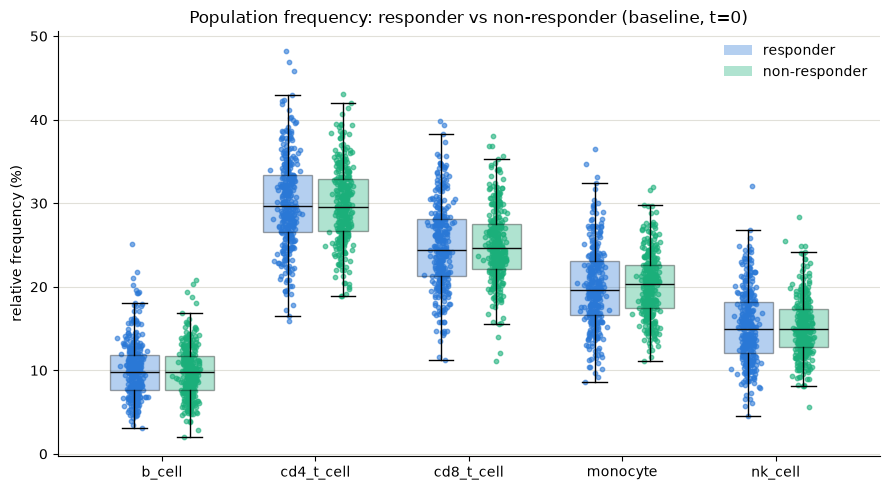

In [3]:
import matplotlib.pyplot as plt
import numpy as np

COLOR_RESPONDER = "#2a78d6"      # categorical slot 1
COLOR_NON_RESPONDER = "#1baf7a"  # categorical slot 2

populations = sorted(freq["population"].unique())
fig, ax = plt.subplots(figsize=(9, 5))

for i, pop in enumerate(populations):
    resp = freq.loc[(freq.population == pop) & (freq.response == "yes"), "percentage"]
    non = freq.loc[(freq.population == pop) & (freq.response == "no"), "percentage"]

    bp = ax.boxplot([resp, non], positions=[i - 0.18, i + 0.18], widths=0.32,
                     patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], [COLOR_RESPONDER, COLOR_NON_RESPONDER]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
    for median in bp["medians"]:
        median.set_color("#0b0b0b")

    rng = np.random.default_rng(0)
    ax.scatter(rng.normal(i - 0.18, 0.03, len(resp)), resp, color=COLOR_RESPONDER, s=10, alpha=0.6)
    ax.scatter(rng.normal(i + 0.18, 0.03, len(non)), non, color=COLOR_NON_RESPONDER, s=10, alpha=0.6)

ax.set_xticks(range(len(populations)))
ax.set_xticklabels(populations)
ax.set_ylabel("relative frequency (%)")
ax.set_title("Population frequency: responder vs non-responder (baseline, t=0)")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_RESPONDER, alpha=0.35),
           plt.Rectangle((0, 0), 1, 1, facecolor=COLOR_NON_RESPONDER, alpha=0.35)]
ax.legend(handles, ["responder", "non-responder"], frameon=False)

plt.tight_layout()
plt.show()

In [4]:
from src.domain.statistics import population_auc, pca_projection

auc_table = population_auc(freq)
pca = pca_projection(freq)
auc_table

,population,auc,auc_abs
0,monocyte,0.471801,0.528199
1,cd8_t_cell,0.485271,0.514729
2,b_cell,0.513539,0.513539
3,cd4_t_cell,0.505824,0.505824
4,nk_cell,0.496742,0.503258


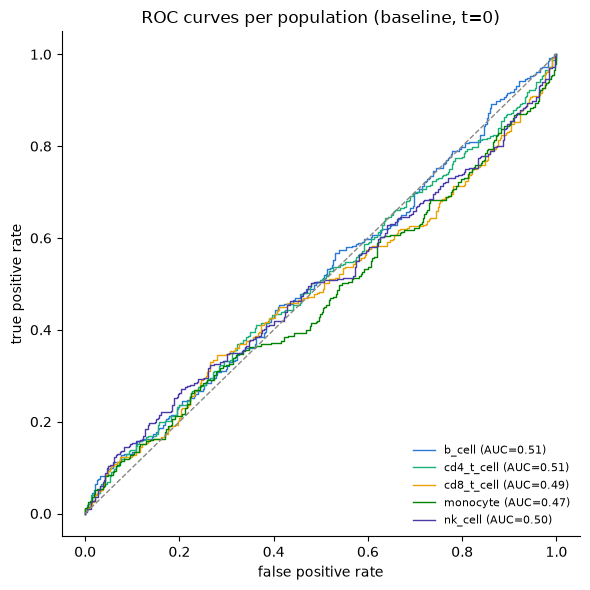

In [5]:
from sklearn.metrics import roc_curve

# fixed categorical order (dataviz palette slots 1-5), not cycled by significance rank
POPULATION_COLORS = {
    "b_cell": "#2a78d6",
    "cd4_t_cell": "#1baf7a",
    "cd8_t_cell": "#eda100",
    "monocyte": "#008300",
    "nk_cell": "#4a3aa7",
}

fig, ax = plt.subplots(figsize=(6, 6))

for population, group in freq.groupby("population"):
    y_true = (group["response"] == "yes").astype(int)
    fpr, tpr, _ = roc_curve(y_true, group["percentage"])
    auc = auc_table.loc[auc_table["population"] == population, "auc"].iloc[0]
    ax.plot(fpr, tpr, color=POPULATION_COLORS[population], linewidth=1,
            label=f"{population} (AUC={auc:.2f})")

ax.plot([0, 1], [0, 1], color="#898781", linewidth=1, linestyle="--")  # chance line
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves per population (baseline, t=0)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## Verify the ported versions in `src/ui/plots.py`

Same plots, now via the actual functions that `run_pipeline.py` will call.

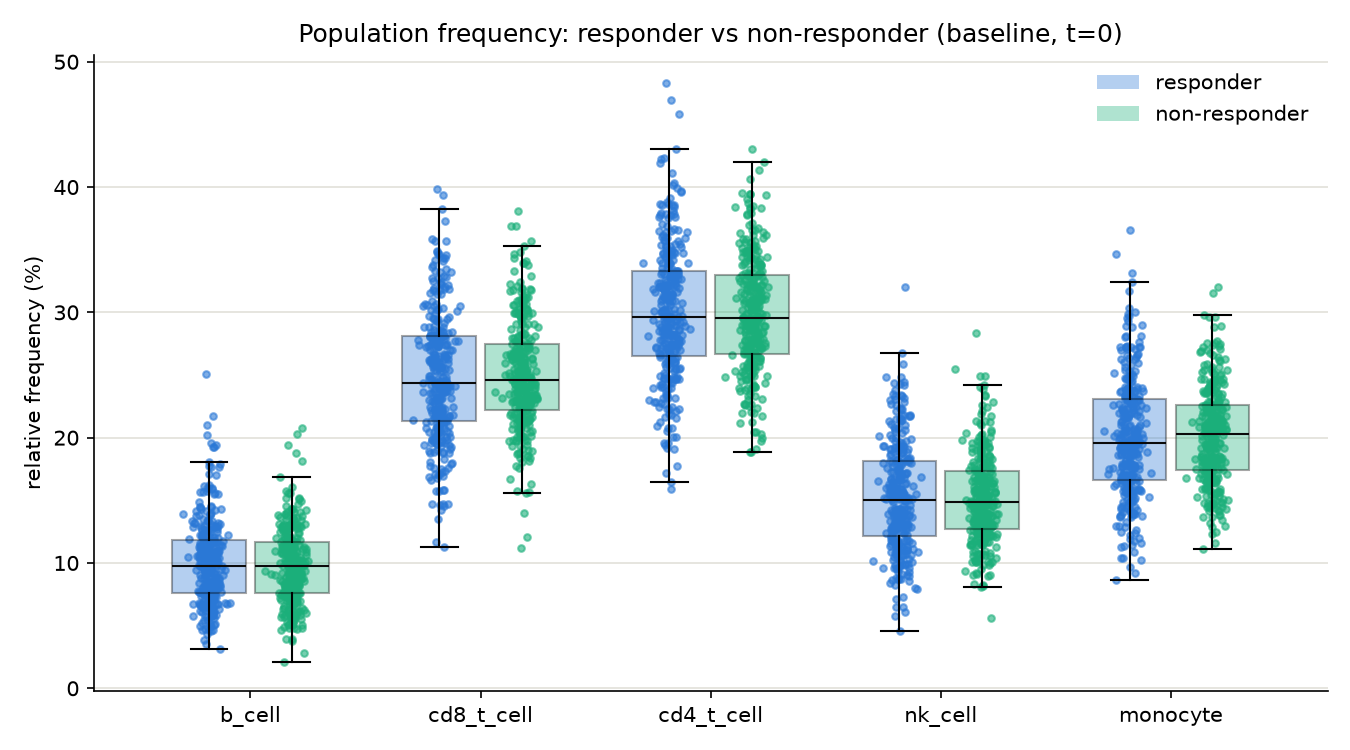

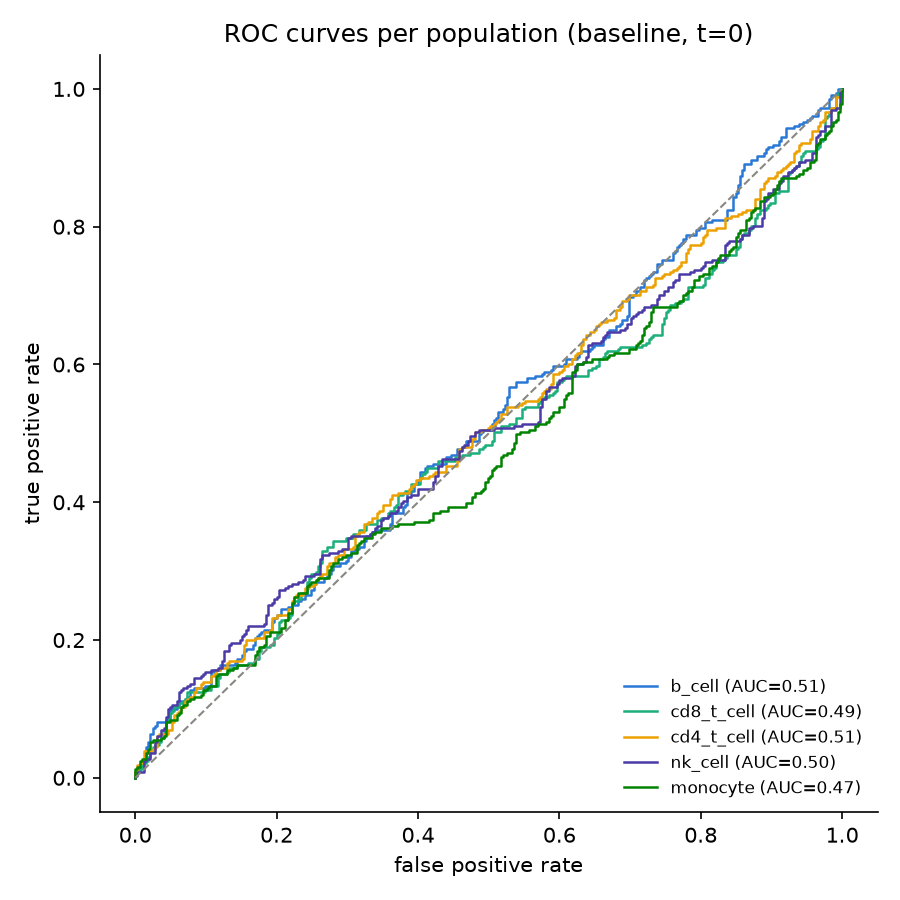

In [6]:
from IPython.display import Image, display
from src.ui.plots import save_boxplots, save_roc_curves

boxplot_path = Path.cwd() / "_preview_boxplots.png"
roc_path = Path.cwd() / "_preview_roc_curves.png"

save_boxplots(freq, path=boxplot_path)
save_roc_curves(freq, auc_table, path=roc_path)

display(Image(filename=str(boxplot_path)))
display(Image(filename=str(roc_path)))

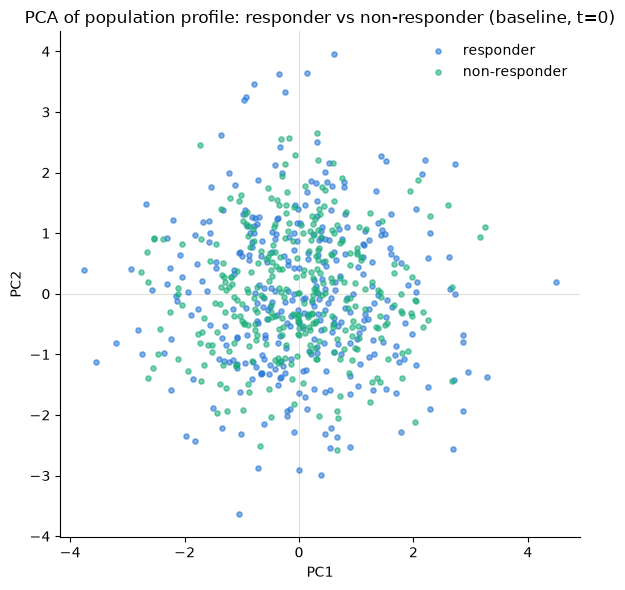

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

for response, color, label in [("yes", COLOR_RESPONDER, "responder"), ("no", COLOR_NON_RESPONDER, "non-responder")]:
    group = pca.loc[pca["response"] == response]
    ax.scatter(group["pc1"], group["pc2"], color=color, s=14, alpha=0.6, label=label)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of population profile: responder vs non-responder (baseline, t=0)")
ax.legend(frameon=False)
ax.axhline(0, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.axvline(0, color="#e1e0d9", linewidth=0.8, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

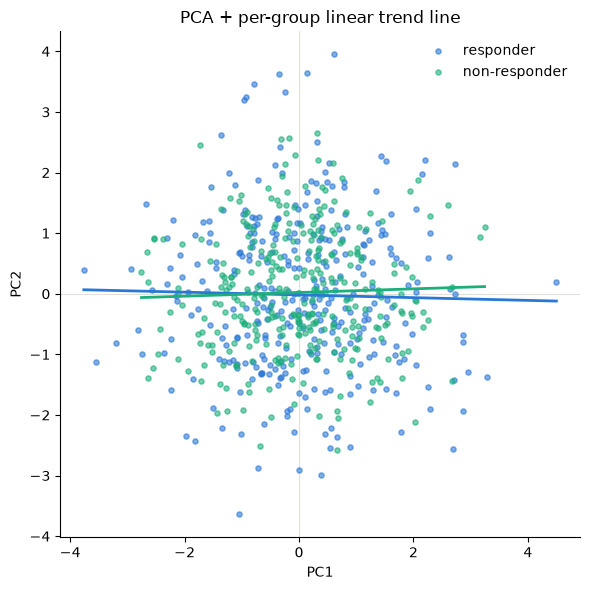

In [8]:
# variant A: per-group linear regression line (PC2 ~ PC1)
fig, ax = plt.subplots(figsize=(6, 6))

for response, color, label in [("yes", COLOR_RESPONDER, "responder"), ("no", COLOR_NON_RESPONDER, "non-responder")]:
    group = pca.loc[pca["response"] == response]
    ax.scatter(group["pc1"], group["pc2"], color=color, s=14, alpha=0.6, label=label)

    slope, intercept = np.polyfit(group["pc1"], group["pc2"], 1)
    x_line = np.array([group["pc1"].min(), group["pc1"].max()])
    ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=2)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA + per-group linear trend line")
ax.legend(frameon=False)
ax.axhline(0, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.axvline(0, color="#e1e0d9", linewidth=0.8, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

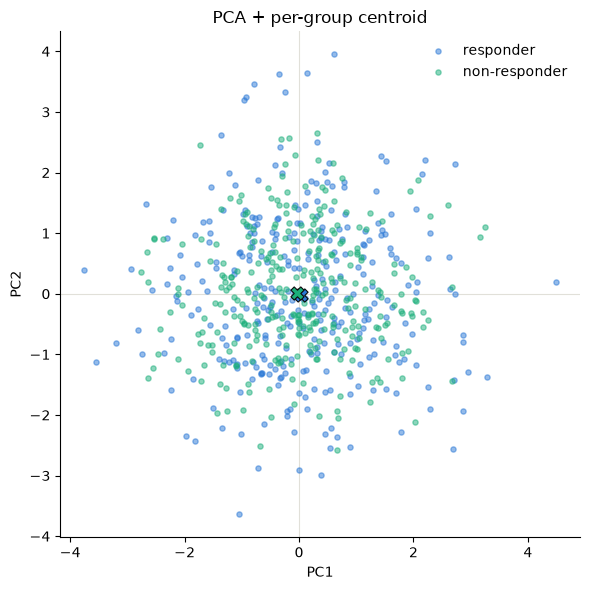

In [9]:
# variant B: per-group centroid marker
fig, ax = plt.subplots(figsize=(6, 6))

for response, color, label in [("yes", COLOR_RESPONDER, "responder"), ("no", COLOR_NON_RESPONDER, "non-responder")]:
    group = pca.loc[pca["response"] == response]
    ax.scatter(group["pc1"], group["pc2"], color=color, s=14, alpha=0.5, label=label)
    ax.scatter(group["pc1"].mean(), group["pc2"].mean(), color=color, s=90, marker="X",
               edgecolor="#0b0b0b", linewidth=0.8, zorder=5)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA + per-group centroid")
ax.legend(frameon=False)
ax.axhline(0, color="#e1e0d9", linewidth=0.8, zorder=0)
ax.axvline(0, color="#e1e0d9", linewidth=0.8, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

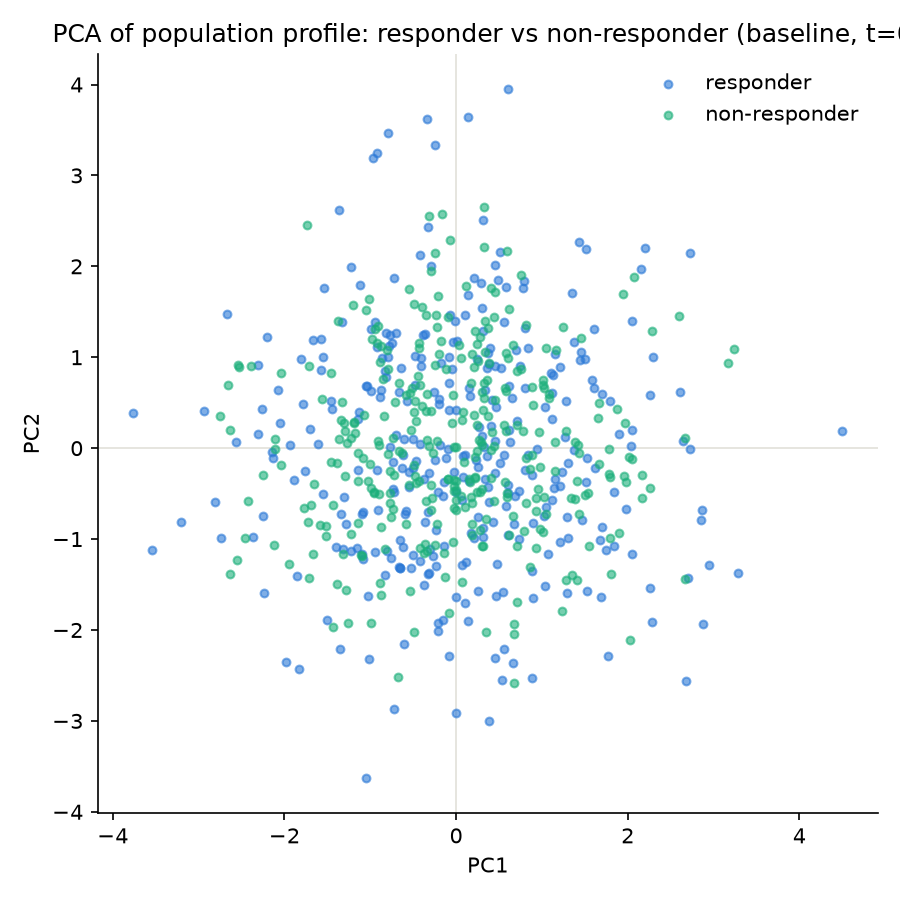

,population,n_responder,n_non_responder,median_responder,median_non_responder,iqr_responder,iqr_non_responder,u_statistic,p_value,cliffs_delta,q_value
0,b_cell,331,325,9.7850,9.7582,4.2117,4.0301,55244.0,0.5485,0.0271,0.8853
1,cd8_t_cell,331,325,24.3957,24.6010,6.7825,5.3268,52203.0,0.5140,-0.0295,0.8853
2,cd4_t_cell,331,325,29.6338,29.5305,6.8157,6.2440,54414.0,0.7964,0.0116,0.8853
3,nk_cell,331,325,14.9973,14.8905,6.0152,4.6345,53437.0,0.8853,-0.0065,0.8853
4,monocyte,331,325,19.6056,20.2860,6.4579,5.1987,50754.0,0.2114,-0.0564,0.8853


In [10]:
from src.ui.plots import save_pca_scatter
from src.ui.tables import save_response_stats

pca_path = Path.cwd() / "_preview_pca.png"
stats_csv_path = Path.cwd() / "_preview_response_stats.csv"

save_pca_scatter(pca, path=pca_path)
save_response_stats(stats, path=stats_csv_path)

display(Image(filename=str(pca_path)))
pd.read_csv(stats_csv_path)

## Reading the three numbers

- **p-value** — probability of seeing a difference this large (or larger) between
  responders and non-responders *if there were actually no real difference* (null
  hypothesis). Small p-value = the observed gap is unlikely to be pure chance.
  Conventional cutoff: p < 0.05. Says nothing about *how big* the difference is,
  and with large n (656 samples here) even a tiny, meaningless difference can get
  a small p-value.
- **q-value** — the p-value after Benjamini-Hochberg (BH) correction for testing
  5 populations at once. Testing 5 hypotheses inflates the chance that at least one
  looks "significant" purely by luck; q-value estimates the false discovery rate if
  we call this population (and everything more extreme) significant. Same
  interpretation convention as p (q < 0.05), but the honest one when multiple
  populations are tested together.
- **Cliff's delta** — nonparametric effect size: how much more often a random
  responder value exceeds a random non-responder value than the reverse. Ranges
  -1 to +1. 0 = no tendency either way, +1 = every responder value beats every
  non-responder value, -1 = the reverse. Unlike p/q, it doesn't shrink just because
  n is large — it's the number that tells us whether a "significant" difference is
  actually *big enough to matter*.

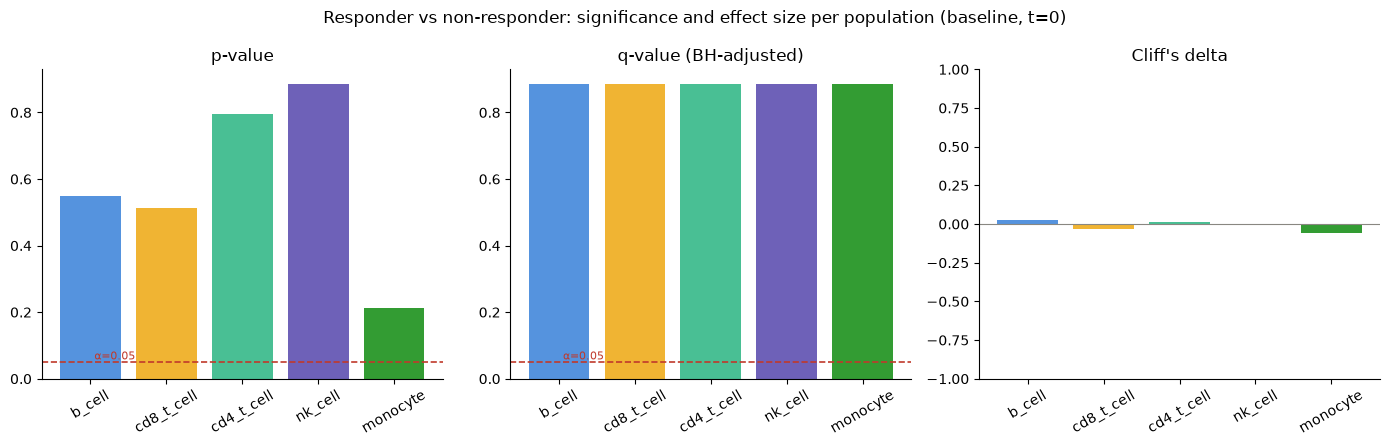

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
bar_colors = [POPULATION_COLORS[pop] for pop in stats["population"]]

for ax, metric, title in zip(axes, ["p_value", "q_value", "cliffs_delta"],
                              ["p-value", "q-value (BH-adjusted)", "Cliff's delta"]):
    ax.bar(stats["population"], stats[metric], color=bar_colors, alpha=0.8)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].axhline(0.05, color="#c0392b", linewidth=1.2, linestyle="--")
axes[0].text(0, 0.05, " α=0.05", color="#c0392b", va="bottom", fontsize=8)

axes[1].axhline(0.05, color="#c0392b", linewidth=1.2, linestyle="--")
axes[1].text(0, 0.05, " α=0.05", color="#c0392b", va="bottom", fontsize=8)

axes[2].axhline(0, color="#898781", linewidth=0.8)
axes[2].set_ylim(-1, 1)

fig.suptitle("Responder vs non-responder: significance and effect size per population (baseline, t=0)")
plt.tight_layout()
plt.show()